#Setup & Acquisition

In [15]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1.Setup Kaggle
dict_token = {"username": "Andaru_Abyan", "key": "KGAT_c3d4fe1e2a5f8d1d5c6a2885796feb17"}
with open('kaggle.json', 'w') as f:
    json.dump(dict_token, f)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 2.Membuat Struktur Folder
os.makedirs('data/raw', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# 3.Download & Extract Dataset
!kaggle datasets download -d amirmohammdjalili/soil-moisture-dataset --force
!unzip -o soil-moisture-dataset.zip -d data/raw/

Dataset URL: https://www.kaggle.com/datasets/amirmohammdjalili/soil-moisture-dataset
License(s): unknown
  0% 0.00/90.9k [00:00<?, ?B/s]
100% 90.9k/90.9k [00:00<00:00, 222MB/s]
Archive:  soil-moisture-dataset.zip
  inflating: data/raw/plant_vase1(2).CSV  
  inflating: data/raw/plant_vase1.CSV  
  inflating: data/raw/plant_vase2.CSV  


#Processing & Analysis

In [16]:
# 4.Data Mentah
df = pd.read_csv('data/raw/plant_vase1.CSV')

# 5.Exploratory Data Analysis
print("INFO STRUKTUR DATA")
print(df.info())

print("\nSTATISTIK DESKRIPTIF")
#rata-rata, min, dan max
print(df.describe())

# 6.Pengecekan Missing Values
missing_per_col = df.isnull().sum()
total_missing = missing_per_col.sum()
total_cells = df.size

print("\nJUMLAH DATA KOSONG")
print(missing_per_col)

# 7. Penghitungan Skor Kualitas Data (Governance)
# Menggunakan rumus dari materi DLM Pertemuan 3
accuracy_score = 1 - (total_missing / total_cells)
completeness_score = (total_cells - total_missing) / total_cells

print("\nDATA QUALITY REPORT")
print(f"Accuracy Score     : {accuracy_score:.4f} (Target: 1.0)")
print(f"Completeness Score : {completeness_score:.4f} (Target: 1.0)")

INFO STRUKTUR DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4117 entries, 0 to 4116
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       4117 non-null   int64  
 1   month      4117 non-null   int64  
 2   day        4117 non-null   int64  
 3   hour       4117 non-null   int64  
 4   minute     4117 non-null   int64  
 5   second     4117 non-null   int64  
 6   moisture0  4117 non-null   float64
 7   moisture1  4117 non-null   float64
 8   moisture2  4117 non-null   float64
 9   moisture3  4117 non-null   float64
 10  moisture4  4117 non-null   float64
 11  irrgation  4117 non-null   bool   
dtypes: bool(1), float64(5), int64(6)
memory usage: 358.0 KB
None

STATISTIK DESKRIPTIF
         year   month          day         hour       minute       second  \
count  4117.0  4117.0  4117.000000  4117.000000  4117.000000  4117.000000   
mean   2020.0     3.0     7.885839    11.109060    29.461744    31.57031

Data Cleaning (Outliers & Transformation)

In [17]:
# 8.kolom sensor yang akan diperiksa
sensor_cols = ['moisture0', 'moisture1', 'moisture2', 'moisture3', 'moisture4']

# 9. Penanganan Outliers dengan Metode IQR
Q1 = df[sensor_cols].quantile(0.25)
Q3 = df[sensor_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Menghapus data yang berada di luar batas
df_cleaned = df[~((df[sensor_cols] < lower_bound) | (df[sensor_cols] > upper_bound)).any(axis=1)].copy()

# 10.Transformasi Datetime: Menggabungkan 6 kolom menjadi 1 timestamp
df_cleaned['timestamp'] = pd.to_datetime(df_cleaned[['year', 'month', 'day', 'hour', 'minute', 'second']])

# 11.Menghapus kolom lama dan merapikan urutan
df_final = df_cleaned.drop(columns=['year', 'month', 'day', 'hour', 'minute', 'second'])
cols = ['timestamp'] + [c for c in df_final.columns if c != 'timestamp']
df_final = df_final[cols]

print(f"Pembersihan Selesai")
print(f"Data awal: {len(df)} baris | Data bersih: {len(df_final)} baris.")

Pembersihan Selesai
Data awal: 4117 baris | Data bersih: 3781 baris.


Visual Analysis

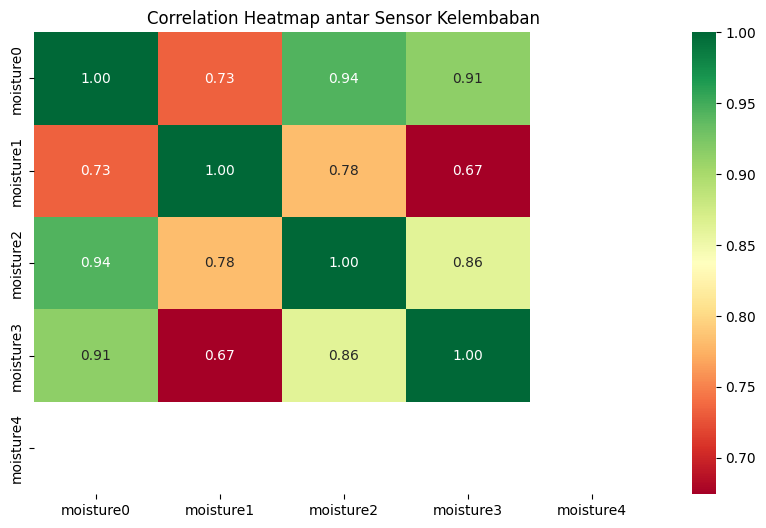

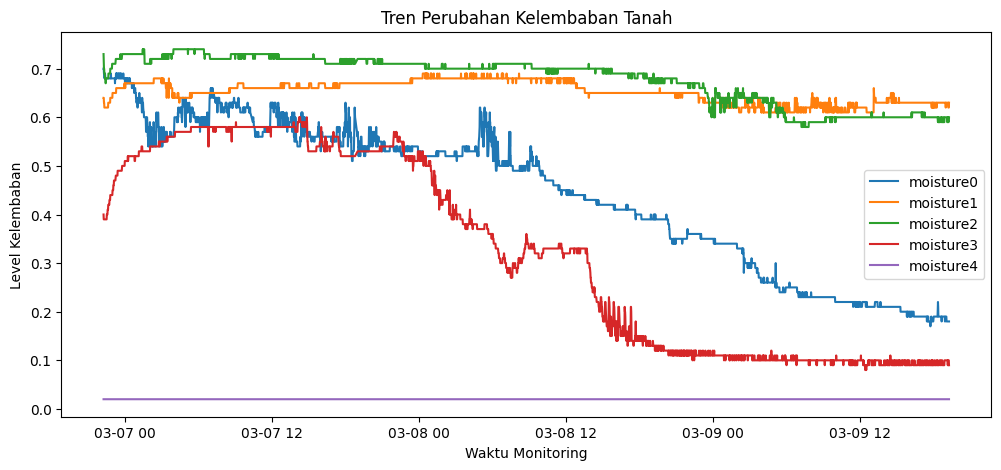

In [18]:
# 12.Correlation Heatmap (Melihat hubungan antar sensor kedalaman)
plt.figure(figsize=(10, 6))
sns.heatmap(df_final[sensor_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlation Heatmap antar Sensor Kelembaban")
plt.show()

# 13.Time Series Trend (Tren Kelembaban terhadap Waktu)
plt.figure(figsize=(12, 5))
for col in sensor_cols:
    plt.plot(df_final['timestamp'], df_final[col], label=col)
plt.title("Tren Perubahan Kelembaban Tanah")
plt.xlabel("Waktu Monitoring")
plt.ylabel("Level Kelembaban")
plt.legend()
plt.show()

export

In [19]:
# 14.Simpan ke folder outputs
df_final.to_csv('outputs/cleaned_data.csv', index=False)
print("SUKSES: File 'cleaned_data.csv' telah tersedia di folder 'outputs'.")

SUKSES: File 'cleaned_data.csv' telah tersedia di folder 'outputs'.
